# Panel Causal Inference Showcase

Compares **SC-ADH**, **SC-DI**, **SC-CL**, **DiD (TWFE)**, and **SDID** across two scenarios:
- **Scenario 1** – `sigma_lambda=0.0`: parallel trends holds  
- **Scenario 2** – `sigma_lambda=1.0`: parallel trends violated

Each figure shows a 1×5 grid of panels (one per estimator) with observed vs. counterfactual,
a 95% CI band in the post period, and a text box comparing estimated vs. true ATT.


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from panelib import did, sc, sdid, dgp

DATA_DICT = {
    'treatment': 'treated',
    'date':      'time',
    'post':      'post',
    'unitid':    'unit_id',
    'outcome':   'y',
}
PARAMS   = dict(seed=42, T_pre=20, T_post=5, N_control=30, noise_sd=0.1, att_pct=0.15)
T_PRE    = PARAMS['T_pre']
THETA_GRID = np.arange(-1.0, 1.5, 0.025)
N_PLACEBO  = 15


In [2]:
df_pt,   true_att_pt   = dgp.simulate_panel(**PARAMS, sigma_lambda=0.0)
df_viol, true_att_viol = dgp.simulate_panel(**PARAMS, sigma_lambda=1.0)

print(f'Scenario 1 (parallel trends)   true ATT = {true_att_pt:.4f}')
print(f'Scenario 2 (PT violated)        true ATT = {true_att_viol:.4f}')
print()
print('Treated unit ID:', df_pt.loc[df_pt['treated']==1, 'unit_id'].iloc[0])


Scenario 1 (parallel trends)   true ATT = 0.3801
Scenario 2 (PT violated)        true ATT = 0.2888

Treated unit ID: u030


In [3]:
print('=== Scenario 1: parallel trends ===')

r1_adh = sc.sc_model(model_name='adh', data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-ADH done')

r1_di  = sc.sc_model(model_name='di',  data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-DI  done')

r1_cl  = sc.sc_model(model_name='cl',  data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-CL  done')

r1_did = did.twfe(data=df_pt, data_dict=DATA_DICT)
print('DiD    done')

r1_sdid = sdid.twfe_sdid(data=df_pt, data_dict=DATA_DICT)
r1_inf  = sdid.sdid_permutation_inference(data=df_pt, data_dict=DATA_DICT,
                                          n_placebo=N_PLACEBO, seed=0)
print('SDID   done')


=== Scenario 1: parallel trends ===
Using ADH


SC-ADH done
Using DI


SC-DI  done
Using CL


SC-CL  done
DiD    done


SDID   done


In [4]:
print('=== Scenario 2: parallel trends violated ===')

r2_adh = sc.sc_model(model_name='adh', data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-ADH done')

r2_di  = sc.sc_model(model_name='di',  data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-DI  done')

r2_cl  = sc.sc_model(model_name='cl',  data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': THETA_GRID})
print('SC-CL  done')

r2_did = did.twfe(data=df_viol, data_dict=DATA_DICT)
print('DiD    done')

r2_sdid = sdid.twfe_sdid(data=df_viol, data_dict=DATA_DICT)
r2_inf  = sdid.sdid_permutation_inference(data=df_viol, data_dict=DATA_DICT,
                                           n_placebo=N_PLACEBO, seed=0)
print('SDID   done')


=== Scenario 2: parallel trends violated ===
Using ADH


SC-ADH done
Using DI


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.908e-01, tolerance: 1.580e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.344e-01, tolerance: 1.784e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.543e-01, tolerance: 9.930e

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e-02, tolerance: 9.681e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.929e-02, tolerance: 2.497e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.936e-01, tolerance: 8.694e

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.985e-01, tolerance: 8.694e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.116e-02, tolerance: 1.914e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.807e-02, tolerance: 3.629e

...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.072e-02, tolerance: 5.674e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.434e-02, tolerance: 3.213e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.953e-02, tolerance: 2.658e

SC-DI  done
Using CL


/home/user/statanomics/workingcode/panelmodels/panelib.py:1480: UserWarning: conformal CI acceptance region is non-contiguous; [ci_lower, ci_upper] may be wider than the true CI. Inspect 'ci_list' for the full accepted theta set.
  warnings.warn(


SC-CL  done
DiD    done


SDID   done


In [5]:
def _extract(model_type, result, df):
    """Return (times, y_obs, y_cf, att, ci_lo, ci_hi) for one estimator."""
    tid = df.loc[df[DATA_DICT['treatment']] == 1, DATA_DICT['unitid']].iloc[0]

    if model_type == 'sc':
        pred  = result['predict_est']
        times = pred.index.to_numpy()
        y_obs = pred[tid].to_numpy()
        y_cf  = pred[f'{tid}_est'].to_numpy()
        att   = float(result['results_df']['atet'].values[0])
        ci_lo = float(result['results_df']['ci_lower'].values[0])
        ci_hi = float(result['results_df']['ci_upper'].values[0])

    elif model_type == 'did':
        r, _  = result, None
        df_c  = r['twfe_c']
        rows  = df_c[df_c[DATA_DICT['unitid']] == tid].sort_values(DATA_DICT['date'])
        times = rows[DATA_DICT['date']].to_numpy()
        y_obs = rows[DATA_DICT['outcome']].to_numpy()
        y_cf  = rows['y_hat_counterfactual'].to_numpy()
        att   = float(r['twfe']['coef_'].iloc[0])
        se    = float(r['twfe']['se_'].iloc[0])
        ci_lo = att - 1.96 * se
        ci_hi = att + 1.96 * se

    elif model_type == 'sdid':
        r_sd, r_inf = result
        cf   = r_sd['counterfactual']
        rows = cf[cf[DATA_DICT['treatment']] == 1].sort_values(DATA_DICT['date'])
        times = rows[DATA_DICT['date']].to_numpy()
        y_obs = rows['y_obs'].to_numpy()
        y_cf  = rows['y_c'].to_numpy()
        att   = r_inf['real_att']
        ci_lo, ci_hi = r_inf['ci']

    return times, y_obs, y_cf, att, ci_lo, ci_hi


def plot_scenario(models, true_att, suptitle):
    """
    models : list of 5 (model_type, result, df) tuples ordered
             [ADH, DI, CL, DiD, SDID]
    """
    colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
    names  = ['SC-ADH', 'SC-DI', 'SC-CL', 'DiD', 'SDID']

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(suptitle, fontsize=13, y=1.02)

    for ax, (mtype, res, df_used), color, name in zip(axes, models, colors, names):
        times, y_obs, y_cf, att, ci_lo, ci_hi = _extract(mtype, res, df_used)

        post = times >= T_PRE

        # Observed treated (black solid)
        ax.plot(times, y_obs, color='black', lw=2, label='Obs. treated')

        # Counterfactual (colored dashed)
        ax.plot(times, y_cf, color=color, lw=2, ls='--', label='Counterfactual')

        # 95 % CI band around counterfactual (post period only)
        # Convention: CF_band_lo = Y_obs - ci_upper, CF_band_hi = Y_obs - ci_lower
        if not (np.isnan(ci_lo) or np.isnan(ci_hi)):
            band_lo = y_obs[post] - ci_hi
            band_hi = y_obs[post] - ci_lo
            ax.fill_between(times[post], band_lo, band_hi,
                            alpha=0.25, color=color, label='95% CI')

        # Treatment onset vertical line
        ax.axvline(x=T_PRE, color='dimgray', ls=':', lw=1.5, label='Treatment onset')

        # ATT text box
        ax.text(0.05, 0.97,
                f'ATT est:  {att:+.3f}\nTrue ATT: {true_att:+.3f}',
                transform=ax.transAxes, va='top', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Time')
        ax.set_ylabel('Outcome')
        ax.legend(fontsize=7, loc='lower left')

    plt.tight_layout()
    plt.show()


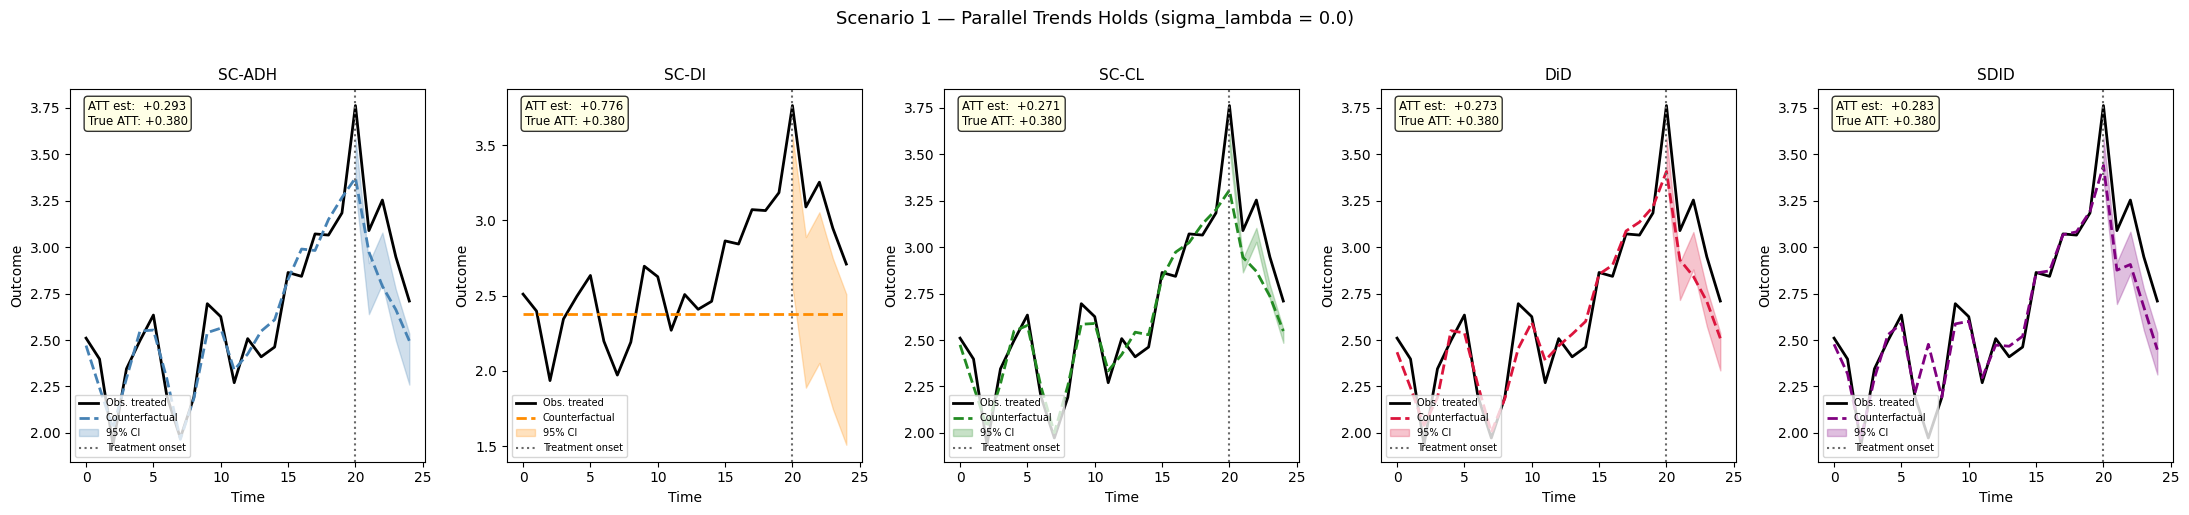

In [6]:
plot_scenario(
    models=[
        ('sc',   r1_adh,            df_pt),
        ('sc',   r1_di,             df_pt),
        ('sc',   r1_cl,             df_pt),
        ('did',  r1_did,            df_pt),
        ('sdid', (r1_sdid, r1_inf), df_pt),
    ],
    true_att=true_att_pt,
    suptitle='Scenario 1 — Parallel Trends Holds (sigma_lambda = 0.0)',
)


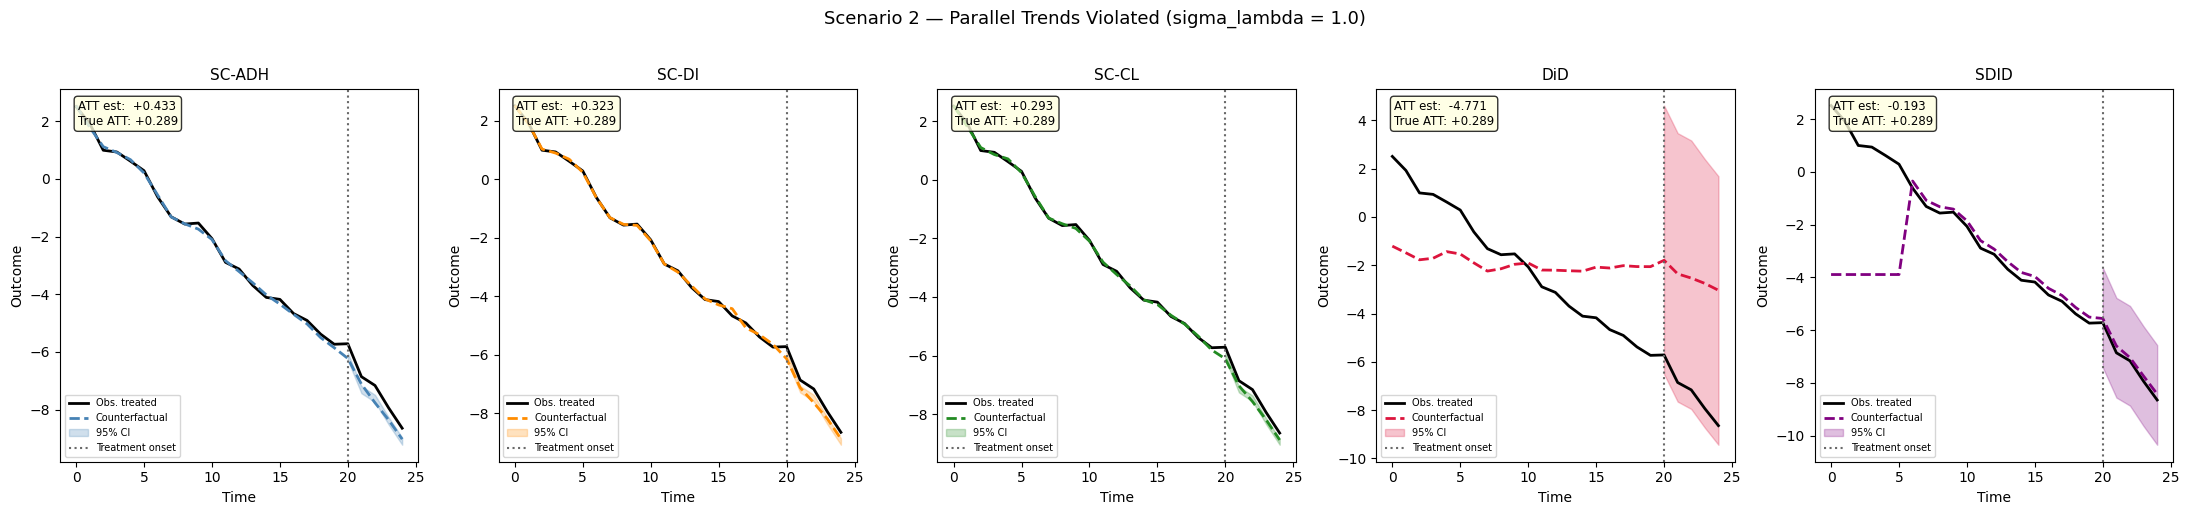

In [7]:
plot_scenario(
    models=[
        ('sc',   r2_adh,            df_viol),
        ('sc',   r2_di,             df_viol),
        ('sc',   r2_cl,             df_viol),
        ('did',  r2_did,            df_viol),
        ('sdid', (r2_sdid, r2_inf), df_viol),
    ],
    true_att=true_att_viol,
    suptitle='Scenario 2 — Parallel Trends Violated (sigma_lambda = 1.0)',
)
